In [1]:
import pandas as pd
import glob
import os

# Directory where your CSV files are located
directory = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/Eplus_files/single_zoning_experiment"

# Pattern to match the CSV files
file_pattern = '*.csv'

# Find all matching file paths
file_paths = glob.glob(os.path.join(directory, file_pattern))

# List to hold all DataFrames
dfs = []

# Read each CSV file into a DataFrame, add filename as a column, and store in dfs list
for file_path in file_paths:
    try:
        # Read CSV file into DataFrame
        df = pd.read_csv(file_path)

        # Extract filename from file_path
        filename = os.path.basename(file_path)

        filename = filename.split("Eplus-env-06-13_thermostat_rbc_eco_case_0_")[-1]

        # Add filename as a column
        df['filename'] = filename

        # Append DataFrame to dfs list
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

# Check if dfs list is empty
if not dfs:
    print("No DataFrames were created. Exiting.")
else:
    # Concatenate all DataFrames into a single DataFrame
    combined_df = pd.concat(dfs, ignore_index=True)

    # Print some information
    print(f"Total CSV files read: {len(dfs)}")
    print(f"Combined DataFrame shape: {combined_df.shape}")



<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


Total CSV files read: 50
Combined DataFrame shape: (50, 24)


In [30]:
baselines = combined_df[combined_df['filename'].str.contains('baseline', case=False)]
baselines.loc[:,"filename"] = baselines.loc[:,"filename"].str.replace("_single_zone_control_manual_baseline-res1.csv","")

baselines = baselines.sort_values(by="filename")

baselines = baselines.reset_index(drop=True)

In [31]:
baselines

,episode_num,cost,gas_cost,electricity_cost,cumulative_reward,mean_reward,cumulative_emissions,mean_emissions,cumulative_comfort_penalty,mean_comfort_penalty,...,comfort_violation (%),mean_comfort_violation,std_comfort_violation,cumulative_comfort_violation,mean_air_quality_violation,std_air_quality_violation,cumulative_air_quality_violation,length(timesteps),time_elapsed(seconds),filename
0,0,163280.886989,163280.886989,0.0,-507776.652801,-9.660895,3408.533424,0.064850,-394.005334,-0.007496,...,8.721461,0.007496,0.073422,3.738026e+07,711.192073,777.801507,394.005334,52560,31536000,rep_0
1,0,163366.071239,163366.071239,0.0,-507025.542992,-9.646605,3411.127907,0.064900,-393.935773,-0.007495,...,8.801370,0.007495,0.077737,3.729818e+07,709.630564,776.416170,393.935773,52560,31536000,rep_1
2,0,163332.685078,163332.685078,0.0,-506406.647108,-9.634830,3408.892053,0.064857,-393.582672,-0.007488,...,8.858447,0.007488,0.071615,3.723906e+07,708.505698,774.073210,393.582672,52560,31536000,rep_2
3,0,163331.620753,163331.620753,0.0,-508910.219357,-9.682462,3409.579648,0.064870,-386.048138,-0.007345,...,8.913623,0.007345,0.073379,3.749026e+07,713.284955,781.801713,386.048138,52560,31536000,rep_3
4,0,163385.756366,163385.756366,0.0,-509854.852237,-9.700435,3409.704905,0.064873,-397.199383,-0.007557,...,8.947869,0.007557,0.073090,3.757918e+07,714.976723,780.971273,397.199383,52560,31536000,rep_4


In [2]:
import pandas as pd

zones = ["hall_downstairs", "front_room", "kitchen", "backroom", "bedroom_3", "bedroom_1", "hall_upstairs", "bathroom", "bedroom_2"]
floor_area = [7.02, 14.0, 8.1, 8.1, 6.9, 14, 5.9, 4.2, 5]

resulting_df = pd.DataFrame()

for r in range(5):
    df = combined_df[combined_df["filename"].str.contains(f"rep_{r}", case=False)]

    baseline = df[df["filename"].str.contains("baseline", case=False)]

    df.loc[:, "cumulative_emissions"] = (1 - df.loc[:, "cumulative_emissions"] / baseline["cumulative_emissions"].values) *100
    df.loc[:, "cost"] = (1-  df.loc[:, "cost"] / baseline["cost"].values) *100

    df = df.sort_values(by="filename")
    df = df[["cost", "cumulative_emissions", "filename"]].iloc[:-1]
    df["Zone"] = zones

    df = df.set_index("Zone")

    schedule = pd.read_csv(f"/workspaces/CUBES/cubes/data/schedules/thermostat_exp/rep{r}/schedule_rep_{r}.sch")

    # Step 1: Convert 'Unnamed: 0' to datetime format
    schedule['Unnamed: 0'] = pd.to_datetime(schedule['Unnamed: 0'], format='%d/%m/%Y %H:%M')

    # Step 2: Filter rows outside of 23:00 to 06:00
    filtered_df = schedule[(schedule['Unnamed: 0'].dt.hour < 23) | (schedule['Unnamed: 0'].dt.hour >= 6)]

    # Step 3: Calculate occupancy percentage for each zone
    total_intervals = len(filtered_df)
    occupancy_percentages = {}

    # Iterate over each column (zone) except for 'Unnamed: 0'
    for column in filtered_df.columns[1:]:
        occupied_count = filtered_df[column].sum()
        occupancy_percent = (occupied_count / total_intervals) * 100
        occupancy_percentages[column] = occupancy_percent

    # Create a new DataFrame from occupancy_percentages dictionary
    occupancy_percentages = pd.DataFrame(list(occupancy_percentages.items()), columns=['Zone', 'percentage_occupied'])

    # Sort the DataFrame by 'OccupancyPercentage'
    occupancy_percentages.sort_values(by='percentage_occupied', ascending=False, inplace=True)
    occupancy_percentages.reset_index(drop=True, inplace=True)
    occupancy_percentages = occupancy_percentages.set_index("Zone")

    df_sorted = pd.concat([df, occupancy_percentages], axis=1)

    df_sorted["floor_area"] = floor_area
    df_sorted["volume"] = df_sorted["floor_area"] *2.7

    out = df_sorted.iloc[:, 0:]  # Exclude the first column ("Zone") for concatenation

    if resulting_df.empty:
        resulting_df = out
    else:
        resulting_df = pd.concat([resulting_df, out], axis=0)

# Reset index of resulting_df for proper alignment
resulting_df = resulting_df.reset_index()


In [4]:
resulting_df.sort_values(by="cumulative_emissions")

,Zone,cost,cumulative_emissions,filename,percentage_occupied,floor_area,volume
24,hall_upstairs,0.737468,0.734629,rep_2_iter_6_single_zone_control_manual-res1.csv,25.993151,5.90,15.930
6,hall_upstairs,0.736333,0.735751,rep_0_iter_6_single_zone_control_manual-res1.csv,25.833333,5.90,15.930
33,hall_upstairs,0.740461,0.736373,rep_3_iter_6_single_zone_control_manual-res1.csv,25.844749,5.90,15.930
15,hall_upstairs,0.740379,0.739427,rep_1_iter_6_single_zone_control_manual-res1.csv,25.833333,5.90,15.930
42,hall_upstairs,0.754719,0.756770,rep_4_iter_6_single_zone_control_manual-res1.csv,25.793379,5.90,15.930
0,hall_downstairs,0.790885,0.835657,rep_0_iter_0_single_zone_control_manual-res1.csv,32.555175,7.02,18.954
2,kitchen,0.808338,0.846959,rep_0_iter_2_single_zone_control_manual-res1.csv,34.455860,8.10,21.870
27,hall_downstairs,0.817195,0.848163,rep_3_iter_0_single_zone_control_manual-res1.csv,32.418189,7.02,18.954
29,kitchen,0.823276,0.855822,rep_3_iter_2_single_zone_control_manual-res1.csv,34.617580,8.10,21.870
36,hall_downstairs,0.824397,0.858849,rep_4_iter_0_single_zone_control_manual-res1.csv,32.682648,7.02,18.954


In [38]:
df

,Zone,cost,cumulative_emissions,filename,percentage_occupied,floor_area,volume
0,hall_downstairs,0.790885,0.835657,rep_0_iter_0_single_zone_control_manual-res1.csv,32.555175,7.02,18.954
9,hall_downstairs,0.830932,0.867479,rep_1_iter_0_single_zone_control_manual-res1.csv,32.397260,7.02,18.954
18,hall_downstairs,0.840287,0.880347,rep_2_iter_0_single_zone_control_manual-res1.csv,32.140411,7.02,18.954
27,hall_downstairs,0.817195,0.848163,rep_3_iter_0_single_zone_control_manual-res1.csv,32.418189,7.02,18.954
36,hall_downstairs,0.824397,0.858849,rep_4_iter_0_single_zone_control_manual-res1.csv,32.682648,7.02,18.954


In [48]:
iterations_df = pd.DataFrame()
for it in range(9):
    df = resulting_df[resulting_df["filename"].str.contains(f"iter_{it}", case=False)]

    df = df[["cost", "cumulative_emissions", "percentage_occupied", "floor_area", "volume"]]

    iter_df = df.mean(skipna=False)

    iter_df["iter"] = f"iter_{it}"

    iter_df = pd.DataFrame(iter_df)

    iterations_df = pd.concat([iterations_df, iter_df.T], axis=0)





In [49]:
iterations_df

,cost,cumulative_emissions,percentage_occupied,floor_area,volume,iter
0,0.820739,0.858099,32.438737,7.02,18.954,iter_0
0,1.185987,1.241905,28.932648,14.0,37.8,iter_1
0,0.831788,0.86397,34.469178,8.1,21.87,iter_2
0,1.141217,1.20931,23.606925,8.1,21.87,iter_3
0,1.350604,1.414318,19.41933,6.9,18.63,iter_4
0,2.277607,2.363927,19.266362,14.0,37.8,iter_5
0,0.741872,0.74059,25.859589,5.9,15.93,iter_6
0,0.995226,1.066226,13.084855,4.2,11.34,iter_7
0,1.174675,1.247305,18.49277,5.0,13.5,iter_8


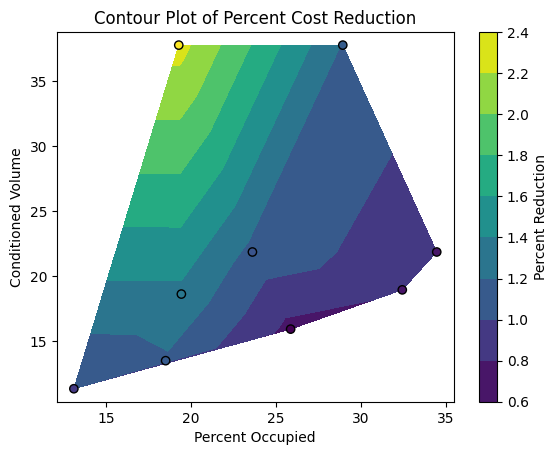

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

df = iterations_df

X = df['percentage_occupied']
Y = df['volume']
Z = df['cost']

x_min, x_max = X.min()-1 , X.max()+1
y_min, y_max = Y.min()-1 , Y.max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 2000), np.linspace(y_min, y_max, 2000))

Z_interp = griddata((X, Y), Z, (xx, yy), method='linear')

plt.contourf(xx, yy, Z_interp, cmap='viridis')
plt.colorbar(label='Percent Reduction')
plt.scatter(X, Y, c=Z, cmap='viridis', edgecolor='black')
plt.xlabel('Percent Occupied')
plt.ylabel('Conditioned Volume')
plt.title('Contour Plot of Percent Cost Reduction')
plt.show()


In [93]:
zones = ["hall_downstairs",
        "front_room",
        "kitchen",
        "backroom",
        "bedroom_3",
        "bedroom_1",
        "hall_upstairs",
        "bathroom",
        "bedroom_2"]

floor_area = [7.02,14.0,8.1,8.1,6.9,14,5.9,4.2,5]


resuting_df = pd.DataFrame()
for r in range(5):
    df = combined_df[combined_df["filename"].str.contains(f"rep_{r}", case=False)]

    baseline = df[df["filename"].str.contains("baseline",case=False)]

    df.loc[:,"cumulative_emissions"] = df.loc[:,"cumulative_emissions"]/baseline["cumulative_emissions"].values
    df.loc[:,"cost"] = df.loc[:,"cost"]/baseline["cost"].values

    df = df.sort_values(by="filename")
    df = df[["cost", "cumulative_emissions", "filename"]].iloc[:-1]
    df["Zone"] = zones

    df = df.set_index("Zone")

    schedule = pd.read_csv(f"/workspaces/CUBES/cubes/data/schedules/thermostat_exp/rep{r}/schedule_rep_{r}.sch")


    # Step 1: Convert 'Unnamed: 0' to datetime format
    schedule['Unnamed: 0'] = pd.to_datetime(schedule['Unnamed: 0'], format='%d/%m/%Y %H:%M')

    # Step 2: Filter rows outside of 23:00 to 06:00
    filtered_df = schedule[(schedule['Unnamed: 0'].dt.hour < 23) | (schedule['Unnamed: 0'].dt.hour >= 6)]

    # Step 3: Calculate occupancy percentage for each zone
    total_intervals = len(filtered_df)
    occupancy_percentages = {}

    # Iterate over each column (zone) except for 'Unnamed: 0'
    for column in filtered_df.columns[1:]:
        occupied_count = filtered_df[column].sum()
        occupancy_percent = (occupied_count / total_intervals) * 100
        occupancy_percentages[column] = occupancy_percent

    # Create a new DataFrame from occupancy_percentages dictionary
    occupancy_percentages = pd.DataFrame(list(occupancy_percentages.items()), columns=['Zone', 'percentage_occupied'])

    # Sort the DataFrame by 'OccupancyPercentage'
    occupancy_percentages.sort_values(by='percentage_occupied', ascending=False, inplace=True)
    occupancy_percentages.reset_index(drop=True, inplace=True)
    occupancy_percentages = occupancy_percentages.set_index("Zone")

    df_sorted = pd.concat([df, occupancy_percentages],axis=1)

    df_sorted["floor_area"] = floor_area

    df_sorted = df_sorted.reset_index()

    out = df_sorted.iloc[:,1:]

    resulting_df = pd.concat([resuting_df, out], axis=1)





In [94]:
resulting_df


,cost,cumulative_emissions,filename,percentage_occupied,floor_area
0,0.991756,0.991412,rep_4_iter_0_single_zone_control_manual-res1.csv,32.682648,7.02
1,0.988282,0.987566,rep_4_iter_1_single_zone_control_manual-res1.csv,28.767123,14.00
2,0.991541,0.991282,rep_4_iter_2_single_zone_control_manual-res1.csv,34.497717,8.10
3,0.988555,0.987824,rep_4_iter_3_single_zone_control_manual-res1.csv,23.580670,8.10
4,0.986602,0.985967,rep_4_iter_4_single_zone_control_manual-res1.csv,19.427321,6.90
5,0.977412,0.976445,rep_4_iter_5_single_zone_control_manual-res1.csv,19.062024,14.00
6,0.992453,0.992432,rep_4_iter_6_single_zone_control_manual-res1.csv,25.793379,5.90
7,0.989947,0.989266,rep_4_iter_7_single_zone_control_manual-res1.csv,13.249619,4.20
8,0.987883,0.987190,rep_4_iter_8_single_zone_control_manual-res1.csv,18.584475,5.00


In [43]:
data_df = combined_df[~combined_df['filename'].str.contains('baseline', case=False)]
rep0 = data_df[data_df["filename"].str.contains("rep_0",case=False)]
rep0 = rep0.sort_values(by="filename")

In [48]:
rep0

,episode_num,cost,gas_cost,electricity_cost,cumulative_reward,mean_reward,cumulative_emissions,mean_emissions,cumulative_comfort_penalty,mean_comfort_penalty,...,comfort_violation (%),mean_comfort_violation,std_comfort_violation,cumulative_comfort_violation,mean_air_quality_violation,std_air_quality_violation,cumulative_air_quality_violation,length(timesteps),time_elapsed(seconds),filename
20,0,161989.522478,161989.522478,0.0,-517494.897608,-9.845793,3380.049785,0.064308,-397.584161,-0.007564,...,8.670091,0.007564,0.074836,3.845737e+07,731.685093,786.653853,397.584161,52560,31536000,rep_0_iter_0_single_zone_control_manual-res1.csv
43,0,161389.759131,161389.759131,0.0,-518846.260468,-9.871504,3367.119750,0.064062,-415.522935,-0.007906,...,8.913623,0.007906,0.075973,3.863978e+07,735.155585,791.568782,415.522935,52560,31536000,rep_0_iter_1_single_zone_control_manual-res1.csv
37,0,161961.026310,161961.026310,0.0,-516541.666366,-9.827657,3379.664533,0.064301,-402.780834,-0.007663,...,8.632040,0.007663,0.075308,3.836386e+07,729.905955,785.579434,402.780834,52560,31536000,rep_0_iter_2_single_zone_control_manual-res1.csv
13,0,161417.984462,161417.984462,0.0,-519076.148242,-9.875878,3367.152905,0.064063,-413.108442,-0.007860,...,8.786149,0.007860,0.075816,3.866070e+07,735.553628,791.525071,413.108442,52560,31536000,rep_0_iter_3_single_zone_control_manual-res1.csv
25,0,161079.526672,161079.526672,0.0,-518544.887257,-9.865770,3360.357189,0.063934,-443.912255,-0.008446,...,8.531202,0.008446,0.082842,3.863218e+07,735.011062,791.598403,443.912255,52560,31536000,rep_0_iter_4_single_zone_control_manual-res1.csv
1,0,159546.991674,159546.991674,0.0,-515742.817418,-9.812458,3327.586566,0.063310,-453.994997,-0.008638,...,8.999239,0.008638,0.081883,3.847634e+07,732.046097,789.561090,453.994997,52560,31536000,rep_0_iter_5_single_zone_control_manual-res1.csv
6,0,162078.596111,162078.596111,0.0,-515726.828322,-9.812154,3383.455121,0.064373,-470.000355,-0.008942,...,8.407534,0.008942,0.085626,3.826603e+07,728.044765,784.786437,470.000355,52560,31536000,rep_0_iter_6_single_zone_control_manual-res1.csv
32,0,161685.570305,161685.570305,0.0,-518783.817228,-9.870316,3372.809272,0.064171,-455.389164,-0.008664,...,8.573059,0.008664,0.083282,3.860535e+07,734.500500,791.981029,455.389164,52560,31536000,rep_0_iter_7_single_zone_control_manual-res1.csv
36,0,161417.714133,161417.714133,0.0,-518477.919496,-9.864496,3367.141743,0.064063,-447.996983,-0.008524,...,8.696728,0.008524,0.081551,3.859741e+07,734.349487,791.259214,447.996983,52560,31536000,rep_0_iter_8_single_zone_control_manual-res1.csv


In [44]:
data_df

,episode_num,cost,gas_cost,electricity_cost,cumulative_reward,mean_reward,cumulative_emissions,mean_emissions,cumulative_comfort_penalty,mean_comfort_penalty,...,comfort_violation (%),mean_comfort_violation,std_comfort_violation,cumulative_comfort_violation,mean_air_quality_violation,std_air_quality_violation,cumulative_air_quality_violation,length(timesteps),time_elapsed(seconds),filename
1,0,159546.991674,159546.991674,0.0,-515742.817418,-9.812458,3327.586566,0.063310,-453.994997,-0.008638,...,8.999239,0.008638,0.081883,3.847634e+07,732.046097,789.561090,453.994997,52560,31536000,rep_0_iter_5_single_zone_control_manual-res1.csv
2,0,161516.086407,161516.086407,0.0,-518061.835002,-9.856580,3370.341597,0.064124,-410.475264,-0.007810,...,8.862253,0.007810,0.079539,3.855150e+07,733.476121,790.291703,410.475264,52560,31536000,rep_1_iter_3_single_zone_control_manual-res1.csv
3,0,161996.882717,161996.882717,0.0,-518875.467077,-9.872060,3380.660839,0.064320,-392.404905,-0.007466,...,8.812785,0.007466,0.075087,3.859534e+07,734.310145,791.142819,392.404905,52560,31536000,rep_3_iter_0_single_zone_control_manual-res1.csv
4,0,162128.159236,162128.159236,0.0,-514140.512500,-9.781973,3383.849359,0.064381,-470.269310,-0.008947,...,8.508371,0.008947,0.082992,3.810332e+07,724.949003,780.861738,470.269310,52560,31536000,rep_2_iter_6_single_zone_control_manual-res1.csv
5,0,162003.668102,162003.668102,0.0,-518942.295524,-9.873331,3379.978468,0.064307,-409.595606,-0.007793,...,8.919330,0.007793,0.076598,3.859975e+07,734.394024,789.306790,409.595606,52560,31536000,rep_4_iter_2_single_zone_control_manual-res1.csv
6,0,162078.596111,162078.596111,0.0,-515726.828322,-9.812154,3383.455121,0.064373,-470.000355,-0.008942,...,8.407534,0.008942,0.085626,3.826603e+07,728.044765,784.786437,470.000355,52560,31536000,rep_0_iter_6_single_zone_control_manual-res1.csv
7,0,162008.609565,162008.609565,0.0,-516718.262111,-9.831017,3381.537084,0.064337,-400.667203,-0.007623,...,8.791857,0.007623,0.079266,3.837784e+07,730.171901,784.934960,400.667203,52560,31536000,rep_1_iter_0_single_zone_control_manual-res1.csv
8,0,161483.169523,161483.169523,0.0,-520148.739660,-9.896285,3368.691020,0.064092,-403.028793,-0.007668,...,8.934551,0.007668,0.075795,3.876363e+07,737.512043,795.613778,403.028793,52560,31536000,rep_3_iter_3_single_zone_control_manual-res1.csv
9,0,161471.274652,161471.274652,0.0,-521125.359499,-9.914866,3367.306956,0.064066,-416.272917,-0.007920,...,8.978311,0.007920,0.075526,3.886094e+07,739.363464,795.155471,416.272917,52560,31536000,rep_4_iter_1_single_zone_control_manual-res1.csv
10,0,159608.416523,159608.416523,0.0,-514551.594340,-9.789794,3328.256264,0.063323,-460.713532,-0.008765,...,9.111492,0.008765,0.079825,3.835152e+07,729.671300,786.928630,460.713532,52560,31536000,rep_2_iter_5_single_zone_control_manual-res1.csv


In [104]:
import os
import pandas as pd

In [106]:
directory = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/single_zoning_experiment"

# List all directories
directories = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]

# Initialize an empty DataFrame
df_list = []


# Iterate over each directory
for d in directories:
    progress_file = os.path.join(directory, d, "progress.csv")
    if os.path.isfile(progress_file):
        # Read the progress.csv file into a DataFrame
        df = pd.read_csv(progress_file)
        # Add a column for directory name
        df['Directory'] = d.split("Eplus-env-06-12_thermostat_rbc_eco_case_0_rep_0_")[-1]
        # Append the DataFrame to the list
        df_list.append(df)

# Concatenate all DataFrames in the list
result_df = pd.concat(df_list, ignore_index=True)

# Drop rows with NaN values only in the "cumulative_reward" column
result_df = result_df.dropna(subset=['cumulative_reward'])

# Assuming df is your DataFrame
df_sorted = result_df.sort_values(by='Directory')

zones = ["hall_downstairs",
        "front_room",
        "kitchen",
        "backroom",
        "bedroom_3",
        "bedroom_1",
        "hall_upstairs",
        "bathroom",
        "bedroom_2",
        "none"]

df_sorted["zones"] = zones



In [107]:
df_sorted = df_sorted.set_index("zones")

In [108]:
df_sorted

,episode_num,cost,gas_cost,electricity_cost,cumulative_reward,mean_reward,cumulative_emissions,mean_emissions,cumulative_comfort_penalty,mean_comfort_penalty,...,comfort_violation (%),mean_comfort_violation,std_comfort_violation,cumulative_comfort_violation,mean_air_quality_violation,std_air_quality_violation,cumulative_air_quality_violation,length(timesteps),time_elapsed(seconds),Directory
zones,,,,,,,,,,,,,,,,,,,,,
hall_downstairs,0,161989.522478,161989.522478,0.0,-517494.897608,-9.845793,3380.049785,0.064308,-397.584161,-0.007564,...,8.670091,0.007564,0.074836,3.845737e+07,731.685093,786.653853,397.584161,52560,31536000,iter_0_zoning_influence_test_manual-res1
front_room,0,161389.759131,161389.759131,0.0,-518846.260468,-9.871504,3367.119750,0.064062,-415.522935,-0.007906,...,8.913623,0.007906,0.075973,3.863978e+07,735.155585,791.568782,415.522935,52560,31536000,iter_1_zoning_influence_test_manual-res1
kitchen,0,161961.026310,161961.026310,0.0,-516541.666366,-9.827657,3379.664533,0.064301,-402.780834,-0.007663,...,8.632040,0.007663,0.075308,3.836386e+07,729.905955,785.579434,402.780834,52560,31536000,iter_2_zoning_influence_test_manual-res1
backroom,0,161417.984462,161417.984462,0.0,-519076.148242,-9.875878,3367.152905,0.064063,-413.108442,-0.007860,...,8.786149,0.007860,0.075816,3.866070e+07,735.553628,791.525071,413.108442,52560,31536000,iter_3_zoning_influence_test_manual-res1
bedroom_3,0,161079.526672,161079.526672,0.0,-518544.887257,-9.865770,3360.357189,0.063934,-443.912255,-0.008446,...,8.531202,0.008446,0.082842,3.863218e+07,735.011062,791.598403,443.912255,52560,31536000,iter_4_zoning_influence_test_manual-res1
bedroom_1,0,159546.991674,159546.991674,0.0,-515742.817418,-9.812458,3327.586566,0.063310,-453.994997,-0.008638,...,8.999239,0.008638,0.081883,3.847634e+07,732.046097,789.561090,453.994997,52560,31536000,iter_5_zoning_influence_test_manual-res1
hall_upstairs,0,162078.596111,162078.596111,0.0,-515726.828322,-9.812154,3383.455121,0.064373,-470.000355,-0.008942,...,8.407534,0.008942,0.085626,3.826603e+07,728.044765,784.786437,470.000355,52560,31536000,iter_6_zoning_influence_test_manual-res1
bathroom,0,161685.570305,161685.570305,0.0,-518783.817228,-9.870316,3372.809272,0.064171,-455.389164,-0.008664,...,8.573059,0.008664,0.083282,3.860535e+07,734.500500,791.981029,455.389164,52560,31536000,iter_7_zoning_influence_test_manual-res1
bedroom_2,0,161417.714133,161417.714133,0.0,-518477.919496,-9.864496,3367.141743,0.064063,-447.996983,-0.008524,...,8.696728,0.008524,0.081551,3.859741e+07,734.349487,791.259214,447.996983,52560,31536000,iter_8_zoning_influence_test_manual-res1


In [70]:
schedule = pd.read_csv("/workspaces/CUBES/cubes/data/schedules/thermostat_exp/rep0/schedule_rep_0.sch")


In [71]:
# Step 1: Convert 'Unnamed: 0' to datetime format
schedule['Unnamed: 0'] = pd.to_datetime(schedule['Unnamed: 0'], format='%d/%m/%Y %H:%M')

# Step 2: Filter rows outside of 23:00 to 06:00
filtered_df = schedule[(schedule['Unnamed: 0'].dt.hour < 23) | (schedule['Unnamed: 0'].dt.hour >= 6)]

# Step 3: Calculate occupancy percentage for each zone
total_intervals = len(filtered_df)
occupancy_percentages = {}

# Iterate over each column (zone) except for 'Unnamed: 0'
for column in filtered_df.columns[1:]:
    occupied_count = filtered_df[column].sum()
    occupancy_percent = (occupied_count / total_intervals) * 100
    occupancy_percentages[column] = occupancy_percent

# Create a new DataFrame from occupancy_percentages dictionary
occupancy_percentages = pd.DataFrame(list(occupancy_percentages.items()), columns=['Zone', 'OccupancyPercentage'])

# Add the 'all' entry with 0% occupancy
all_entry = pd.DataFrame([{'Zone': 'none', 'OccupancyPercentage': 0}])
occupancy_percentages = pd.concat([occupancy_percentages, all_entry], ignore_index=True)

# Sort the DataFrame by 'OccupancyPercentage'
occupancy_percentages.sort_values(by='OccupancyPercentage', ascending=False, inplace=True)
occupancy_percentages.reset_index(drop=True, inplace=True)
occupancy_percentages = occupancy_percentages.set_index("Zone")

In [72]:
occupancy_percentages

,OccupancyPercentage
Zone,
kitchen,34.455860
hall_downstairs,32.555175
front_room,29.096271
hall_upstairs,25.833333
backroom,23.691020
bedroom_3,19.391172
bedroom_1,19.261796
bedroom_2,18.369482
bathroom,13.061263


In [93]:
df_sorted = pd.concat([df_sorted, occupancy_percentages],axis=1)

In [94]:
df_sorted["floor_area"] = [7.02,14.0,8.1,8.1,6.9,14,5.9,4.2,5,0]

In [95]:
df_sorted

,episode_num,cost,gas_cost,electricity_cost,cumulative_reward,mean_reward,cumulative_emissions,mean_emissions,cumulative_comfort_penalty,mean_comfort_penalty,...,cumulative_comfort_violation,mean_air_quality_violation,std_air_quality_violation,cumulative_air_quality_violation,length(timesteps),time_elapsed(seconds),Directory,floor_area,percent_reduction,OccupancyPercentage
hall_downstairs,0,161989.522478,161989.522478,0.0,-517494.897608,-9.845793,3380.049785,0.064308,-397.584161,-0.007564,...,3.845737e+07,731.685093,786.653853,397.584161,52560,31536000,iter_0_zoning_influence_test_manual-res1,7.02,0.976329,32.555175
front_room,0,161389.759131,161389.759131,0.0,-518846.260468,-9.871504,3367.119750,0.064062,-415.522935,-0.007906,...,3.863978e+07,735.155585,791.568782,415.522935,52560,31536000,iter_1_zoning_influence_test_manual-res1,14.00,0.972594,29.096271
kitchen,0,161961.026310,161961.026310,0.0,-516541.666366,-9.827657,3379.664533,0.064301,-402.780834,-0.007663,...,3.836386e+07,729.905955,785.579434,402.780834,52560,31536000,iter_2_zoning_influence_test_manual-res1,8.10,0.976217,34.455860
backroom,0,161417.984462,161417.984462,0.0,-519076.148242,-9.875878,3367.152905,0.064063,-413.108442,-0.007860,...,3.866070e+07,735.553628,791.525071,413.108442,52560,31536000,iter_3_zoning_influence_test_manual-res1,8.10,0.972603,23.691020
bedroom_3,0,161079.526672,161079.526672,0.0,-518544.887257,-9.865770,3360.357189,0.063934,-443.912255,-0.008446,...,3.863218e+07,735.011062,791.598403,443.912255,52560,31536000,iter_4_zoning_influence_test_manual-res1,6.90,0.970640,19.391172
bedroom_1,0,159546.991674,159546.991674,0.0,-515742.817418,-9.812458,3327.586566,0.063310,-453.994997,-0.008638,...,3.847634e+07,732.046097,789.561090,453.994997,52560,31536000,iter_5_zoning_influence_test_manual-res1,14.00,0.961175,19.261796
hall_upstairs,0,162078.596111,162078.596111,0.0,-515726.828322,-9.812154,3383.455121,0.064373,-470.000355,-0.008942,...,3.826603e+07,728.044765,784.786437,470.000355,52560,31536000,iter_6_zoning_influence_test_manual-res1,5.90,0.977312,25.833333
bathroom,0,161685.570305,161685.570305,0.0,-518783.817228,-9.870316,3372.809272,0.064171,-455.389164,-0.008664,...,3.860535e+07,734.500500,791.981029,455.389164,52560,31536000,iter_7_zoning_influence_test_manual-res1,4.20,0.974237,13.061263
bedroom_2,0,161417.714133,161417.714133,0.0,-518477.919496,-9.864496,3367.141743,0.064063,-447.996983,-0.008524,...,3.859741e+07,734.349487,791.259214,447.996983,52560,31536000,iter_8_zoning_influence_test_manual-res1,5.00,0.972600,18.369482
none,0,161989.522478,161989.522478,0.0,-517494.897608,-9.845793,3380.049785,0.064308,-397.584161,-0.007564,...,3.845737e+07,731.685093,786.653853,397.584161,52560,31536000,zoning_influence_test_baseline_manual-res1,0.00,0.976329,0.000000


In [96]:
df_sorted["percent_reduction"] = df_sorted["cumulative_emissions"]/3462

In [97]:
df_sorted

,episode_num,cost,gas_cost,electricity_cost,cumulative_reward,mean_reward,cumulative_emissions,mean_emissions,cumulative_comfort_penalty,mean_comfort_penalty,...,cumulative_comfort_violation,mean_air_quality_violation,std_air_quality_violation,cumulative_air_quality_violation,length(timesteps),time_elapsed(seconds),Directory,floor_area,percent_reduction,OccupancyPercentage
hall_downstairs,0,161989.522478,161989.522478,0.0,-517494.897608,-9.845793,3380.049785,0.064308,-397.584161,-0.007564,...,3.845737e+07,731.685093,786.653853,397.584161,52560,31536000,iter_0_zoning_influence_test_manual-res1,7.02,0.976329,32.555175
front_room,0,161389.759131,161389.759131,0.0,-518846.260468,-9.871504,3367.119750,0.064062,-415.522935,-0.007906,...,3.863978e+07,735.155585,791.568782,415.522935,52560,31536000,iter_1_zoning_influence_test_manual-res1,14.00,0.972594,29.096271
kitchen,0,161961.026310,161961.026310,0.0,-516541.666366,-9.827657,3379.664533,0.064301,-402.780834,-0.007663,...,3.836386e+07,729.905955,785.579434,402.780834,52560,31536000,iter_2_zoning_influence_test_manual-res1,8.10,0.976217,34.455860
backroom,0,161417.984462,161417.984462,0.0,-519076.148242,-9.875878,3367.152905,0.064063,-413.108442,-0.007860,...,3.866070e+07,735.553628,791.525071,413.108442,52560,31536000,iter_3_zoning_influence_test_manual-res1,8.10,0.972603,23.691020
bedroom_3,0,161079.526672,161079.526672,0.0,-518544.887257,-9.865770,3360.357189,0.063934,-443.912255,-0.008446,...,3.863218e+07,735.011062,791.598403,443.912255,52560,31536000,iter_4_zoning_influence_test_manual-res1,6.90,0.970640,19.391172
bedroom_1,0,159546.991674,159546.991674,0.0,-515742.817418,-9.812458,3327.586566,0.063310,-453.994997,-0.008638,...,3.847634e+07,732.046097,789.561090,453.994997,52560,31536000,iter_5_zoning_influence_test_manual-res1,14.00,0.961175,19.261796
hall_upstairs,0,162078.596111,162078.596111,0.0,-515726.828322,-9.812154,3383.455121,0.064373,-470.000355,-0.008942,...,3.826603e+07,728.044765,784.786437,470.000355,52560,31536000,iter_6_zoning_influence_test_manual-res1,5.90,0.977312,25.833333
bathroom,0,161685.570305,161685.570305,0.0,-518783.817228,-9.870316,3372.809272,0.064171,-455.389164,-0.008664,...,3.860535e+07,734.500500,791.981029,455.389164,52560,31536000,iter_7_zoning_influence_test_manual-res1,4.20,0.974237,13.061263
bedroom_2,0,161417.714133,161417.714133,0.0,-518477.919496,-9.864496,3367.141743,0.064063,-447.996983,-0.008524,...,3.859741e+07,734.349487,791.259214,447.996983,52560,31536000,iter_8_zoning_influence_test_manual-res1,5.00,0.972600,18.369482
none,0,161989.522478,161989.522478,0.0,-517494.897608,-9.845793,3380.049785,0.064308,-397.584161,-0.007564,...,3.845737e+07,731.685093,786.653853,397.584161,52560,31536000,zoning_influence_test_baseline_manual-res1,0.00,0.976329,0.000000


In [98]:
results = df_sorted[["OccupancyPercentage", "floor_area", "percent_reduction"]]

In [64]:
results

,OccupancyPercentage,floor_area,percent_reduction
7,18.369482,7.02,0.976329
5,19.391172,14.00,0.972594
9,0.000000,8.10,0.976217
6,19.261796,8.10,0.972603
0,34.455860,6.90,0.970640
2,29.096271,14.00,0.961175
1,32.555175,5.90,0.977312
4,23.691020,4.20,0.974237
3,25.833333,5.00,0.972600
8,13.061263,0.00,0.976329


In [99]:
results["volume"] = results["floor_area"]*2.7

/tmp/ipykernel_3113/1991636334.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results["volume"] = results["floor_area"]*2.7


In [102]:
results = results.iloc[:-1,:]

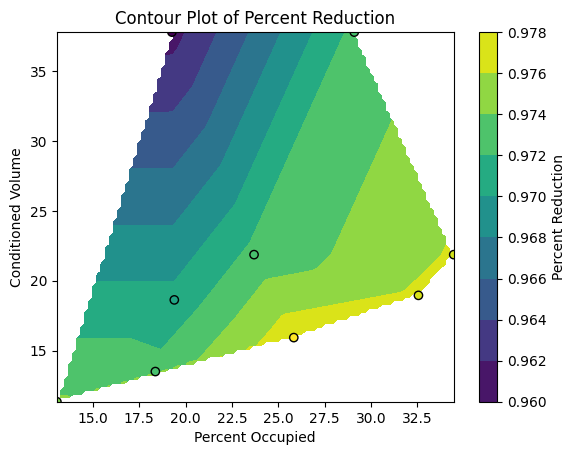

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

df = results

X = df['OccupancyPercentage']
Y = df['volume']
Z = df['percent_reduction']

x_min, x_max = X.min() , X.max()
y_min, y_max = Y.min() , Y.max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

Z_interp = griddata((X, Y), Z, (xx, yy), method='linear')

plt.contourf(xx, yy, Z_interp, cmap='viridis')
plt.colorbar(label='Percent Reduction')
plt.scatter(X, Y, c=Z, cmap='viridis', edgecolor='black')
plt.xlabel('Percent Occupied')
plt.ylabel('Conditioned Volume')
plt.title('Contour Plot of Percent Reduction')
plt.show()
